# 1. Setup and Imports

In [1]:
from pathlib import Path
from matplotlib.ticker import FuncFormatter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Load Dataset
The dataset used in this project is the Online Retail dataset sourced from Kaggle. 
The CSV file is stored locally in the `/data` folder and loaded using pandas. 
The encoding is set to `ISO-8859-1` to avoid character encoding issues commonly associated with this dataset.

In [2]:
DATA_PATH = Path("../data/OnlineRetail.csv")
df_raw = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# 3. Data Overview
This section examines the structure of the dataset, including data types, missing values, and summary statistics.

Basic dataset check

In [3]:
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])
df_raw.info()
df_raw.describe()

Rows: 541909
Columns: 8
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Preview columns and missing values

In [4]:
display(df_raw.head())
display(df_raw.isna().sum())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Check the count of unique products, customers, and invoices

In [5]:
df_raw.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

Check for duplicates records

In [6]:
df_raw.duplicated().sum()

np.int64(5268)

Check for zero or negative prices

In [7]:
df_raw[df_raw["UnitPrice"] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom


Check for cancelled transactions (invoice numbers with "C")

In [8]:
df_raw[df_raw["InvoiceNo"].astype(str).str.startswith("C")].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


# 4. Data Cleaning


Data preprocessing was conducted in two stages. First, structural issues such as missing customer identifiers and duplicate records were removed to produce a cleaned dataset (`df_clean`). 

Second, a modelling dataset (`df_model`) was created by excluding cancelled transactions and product returns, ensuring that only valid sales data was used for analysis.

FOR REPORT: The dataset is processed in two stages. First, structural cleaning is performed to remove invalid records such as duplicates and entries with missing customer identifiers, resulting in a cleaned dataset (df_clean). Subsequently, a modelling dataset (df_model) is created by excluding returns and cancelled transactions to ensure that only valid sales were used for analysis. This separation allowed for both accurate modelling and the preservation of operational insights related to returns and cancellations.

Maintaining multiple dataset versions ensured that data preprocessing decisions remained transparent and reversible, while enabling different analytical perspectives.

Create clean dataset

In [9]:
df_clean = df_raw.copy()
df_clean = df_clean.dropna(subset=["CustomerID"])
df_clean = df_clean.drop_duplicates()
df_clean = df_clean[df_clean["UnitPrice"] > 0]
#Negative quantities were retained only where they correspond to cancellation transactions, identified by invoice numbers beginning with “C”. This ensured that valid cancellation records were preserved for subsequent matching, while excluding anomalous negative values.
df_clean = df_clean[
    (df_clean["Quantity"] > 0) |
    (
        (df_clean["Quantity"] < 0) &
        (df_clean["InvoiceNo"].astype(str).str.startswith("C"))
    )
]
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])


Quick validation check

In [10]:
df_clean.info()
df_clean.describe()

<class 'pandas.DataFrame'>
Index: 401564 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401564 non-null  str           
 1   StockCode    401564 non-null  str           
 2   Description  401564 non-null  str           
 3   Quantity     401564 non-null  int64         
 4   InvoiceDate  401564 non-null  datetime64[us]
 5   UnitPrice    401564 non-null  float64       
 6   CustomerID   401564 non-null  float64       
 7   Country      401564 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 27.6 MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,401564.000000,401564,401564.000000,401564.000000
mean,12.149911,2011-07-10 12:06:07.514568,3.474410,15281.266797
min,-80995.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000
50%,5.000000,2011-07-29 15:32:30,1.950000,15145.000000
75%,12.000000,2011-10-20 11:58:00,3.750000,16788.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,249.512649,NaN,69.767501,1713.978947


Create modelling dataset

In [28]:
#split clean dataset by cancellations and sales
sales = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
].copy()

cancellations = df_clean[
    df_clean["InvoiceNo"].astype(str).str.startswith("C")
].copy()

#Prepare for mathcing by sortng by invoce date
sales = sales.sort_values("InvoiceDate")
cancellations = cancellations.sort_values("InvoiceDate")

#Match cancellations to original sales (1-to-1)
matched_sales = set()
matched_cancellations = set()

for idx, cancel in cancellations.iterrows():
    
    candidates = sales[
        (sales["CustomerID"] == cancel["CustomerID"]) &
        (sales["StockCode"] == cancel["StockCode"]) &
        (sales["UnitPrice"] == cancel["UnitPrice"]) &
        (sales["Quantity"] == -cancel["Quantity"])
    ]
    
    # Exclude already matched sales
    candidates = candidates[~candidates.index.isin(matched_sales)]
    
    if not candidates.empty:
        match = candidates.iloc[0]  # closest in time
        
        matched_sales.add(match.name)
        matched_cancellations.add(idx)

#Remove matched transactions
df_model = df_clean.drop(
    index=list(matched_sales) + list(matched_cancellations)
).copy()
# Final modelling filter: keep only valid positive sales
df_model = df_model[
    (df_model["Quantity"] > 0) &
    (~df_model["InvoiceNo"].astype(str).str.startswith("C")) &
    (df_model["UnitPrice"] > 0)
].copy()
df_model = df_model.set_index("InvoiceDate")


FOR REPORT: The dataset contains 541,909 records, of which approximately 24.9% lack customer identifiers. This highlights a significant limitation for customer-level analysis, as a substantial portion of transactions cannot be linked to individual customers. Additionally, 5,268 duplicate records were identified, representing approximately 1% of the dataset. Only a small fraction of these duplicates (43 records) were associated with missing customer identifiers, indicating that duplication is not primarily driven by incomplete data but may result from system-level recording issues.The relatively low proportion of duplicate records suggests that duplication has a limited impact on overall dataset integrity, but removal is still necessary to prevent double-counting in analysis.

In [29]:
print("Raw:", len(df_raw))
missing_customer = df_raw["CustomerID"].isna().sum()
print("Records with missing CustomerID:", missing_customer)
total_duplicates = df_raw.duplicated().sum()
print("Total duplicate records:", total_duplicates)
duplicates_missing_customer = df_raw[
    df_raw.duplicated() & df_raw["CustomerID"].isna()
].shape[0]
print("duplicates_missing_customer", duplicates_missing_customer)
print("Negative quantities in df_model:", (df_model["Quantity"] < 0).sum())
print("Cancellation invoices in df_model:", df_model["InvoiceNo"].astype(str).str.startswith("C").sum())

Raw: 541909
Records with missing CustomerID: 135080
Total duplicate records: 5268
duplicates_missing_customer 43
Negative quantities in df_model: 0
Cancellation invoices in df_model: 0


Add TotalPrice Feature

In [30]:
df_model["TotalPrice"] = df_model["Quantity"] * df_model["UnitPrice"]

Model Dataset validation

In [31]:
df_model.info()
df_model.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 389641 entries, 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    389641 non-null  str    
 1   StockCode    389641 non-null  str    
 2   Description  389641 non-null  str    
 3   Quantity     389641 non-null  int64  
 4   UnitPrice    389641 non-null  float64
 5   CustomerID   389641 non-null  float64
 6   Country      389641 non-null  str    
 7   TotalPrice   389641 non-null  float64
dtypes: float64(3), int64(1), str(4)
memory usage: 26.8 MB


,Quantity,UnitPrice,CustomerID,TotalPrice
count,389641.000000,389641.000000,389641.00000,389641.000000
mean,12.643936,3.009797,15289.80608,21.700013
std,42.273308,13.654276,1713.33754,93.450614
min,1.000000,0.001000,12347.00000,0.001000
25%,2.000000,1.250000,13956.00000,4.950000
50%,6.000000,1.950000,15152.00000,11.900000
75%,12.000000,3.750000,16794.00000,19.800000
max,4800.000000,4161.060000,18287.00000,38970.000000


# 5. Exploratory Data Analysis
This section explores patterns in customer behaviour, product sales, and transaction trends using the cleaned and modelling datasets.

Total Revenue

In [32]:
total_revenue = df_model["TotalPrice"].sum()
print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 8455214.73


Invoice analysis
FOR REPORT: The number of items per transaction was analysed to understand customer purchasing behaviour. The results indicate that most transactions consist of a small number of items, suggesting that customers typically make low-volume purchases. However, a small number of transactions contain a large number of items, indicating potential bulk purchasing behaviour.

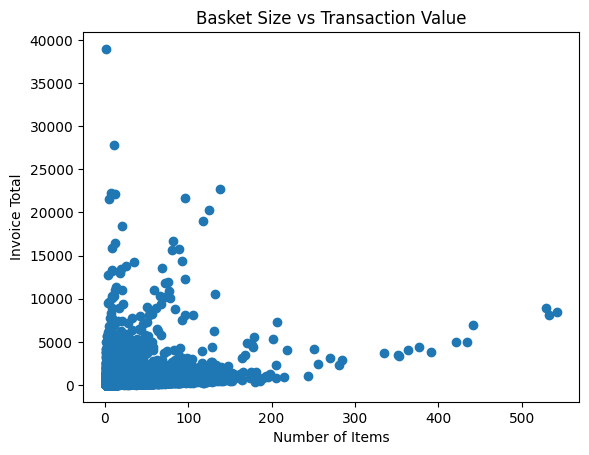

In [33]:

#Price per Invoice
invoice_totals = (
    df_model.groupby("InvoiceNo")["TotalPrice"]
    .sum()
)
# Items per Invoice
items_per_invoice = (
    df_model.groupby("InvoiceNo")
    .size()
)
#Invoice Summary
invoice_summary = df_model.groupby("InvoiceNo").agg({
    "TotalPrice": "sum",
    "Quantity": "sum"
})

invoice_summary["NumItems"] = items_per_invoice

plt.scatter(invoice_summary["NumItems"], invoice_summary["TotalPrice"])
plt.xlabel("Number of Items")
plt.ylabel("Invoice Total")
plt.title("Basket Size vs Transaction Value")
plt.show()

Customer Analysis
FOR REPORT: Customer-level analysis reveals that the majority of customers make only a small number of purchases and contribute relatively low total revenue. However, a small subset of customers accounts for a disproportionately large share of total sales. This indicates a highly skewed customer value distribution, suggesting opportunities for targeted marketing and customer retention strategies.

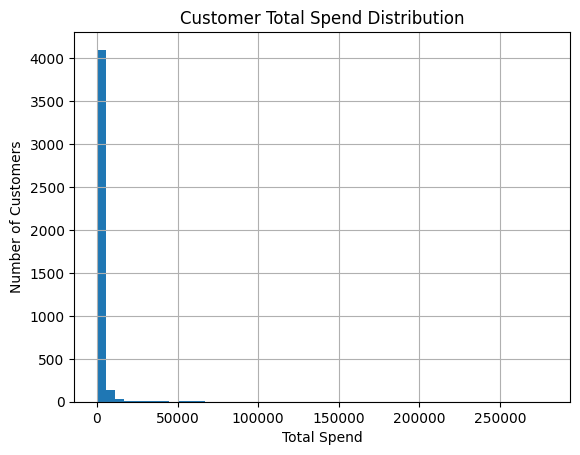

In [34]:
#Total sales per customer
customer_sales = (
    df_model.groupby("CustomerID")["TotalPrice"]
    .sum()
)
customer_sales.hist(bins=50)
plt.title("Customer Total Spend Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.show()

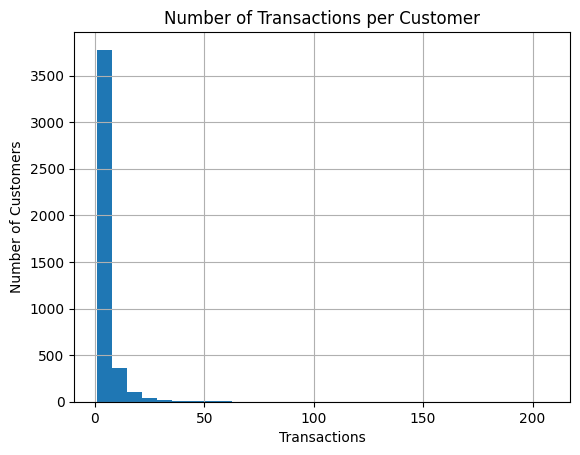

In [35]:
#Total transactions per customer
customer_transactions = (
    df_model.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)
customer_transactions.hist(bins=30)
plt.title("Number of Transactions per Customer")
plt.xlabel("Transactions")
plt.ylabel("Number of Customers")
plt.show()

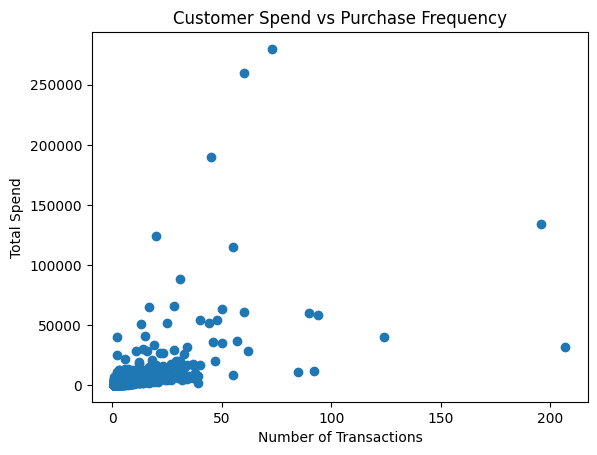

In [36]:
#Customer Summary
customer_summary = df_model.groupby("CustomerID").agg({
    "TotalPrice": "sum",
    "InvoiceNo": "nunique"
})

customer_summary.columns = ["TotalSpend", "NumTransactions"]
#Relationship between spend & frequency
plt.scatter(
    customer_summary["NumTransactions"],
    customer_summary["TotalSpend"]
)

plt.xlabel("Number of Transactions")
plt.ylabel("Total Spend")
plt.title("Customer Spend vs Purchase Frequency")
plt.show()

Product Analysis

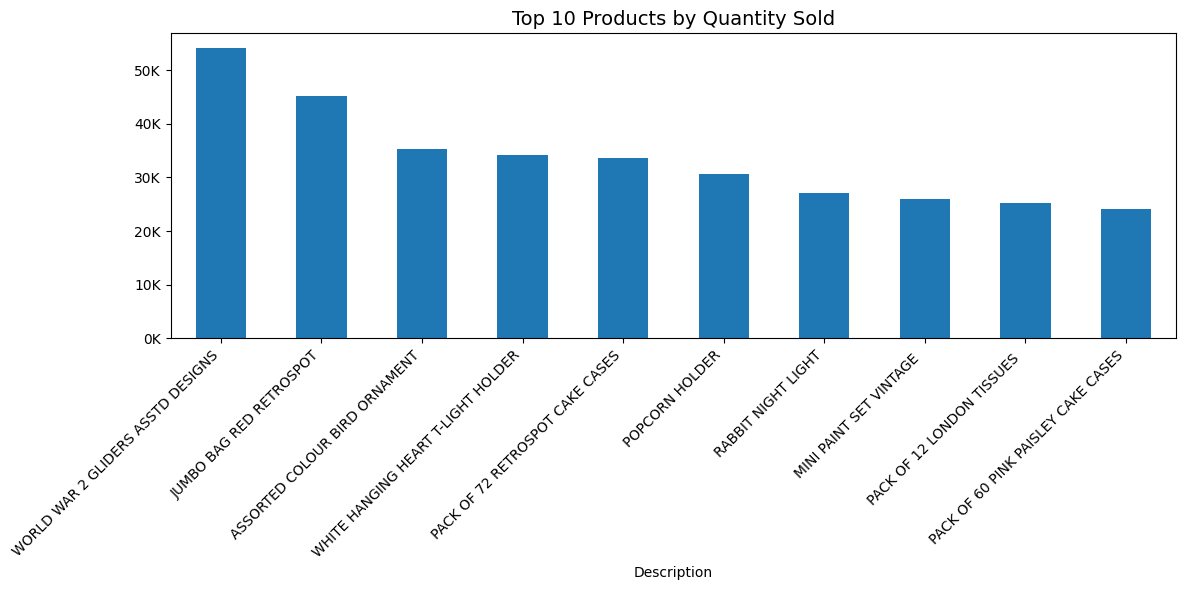

In [37]:
#Top-selling products (by quantity)
top_products = (
    df_model.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
ax = top_products.plot(kind="bar", figsize=(12, 6))

# Title
plt.title("Top 10 Products by Quantity Sold", fontsize=14)

# Format y-axis to show values in 'K'
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1000)}K'))

# Rotate x-axis labels and make them smaller
plt.xticks(rotation=45, ha='right', fontsize=10)

# Optional: adjust layout so labels fit nicely
plt.tight_layout()

plt.show()

Top products by revenue

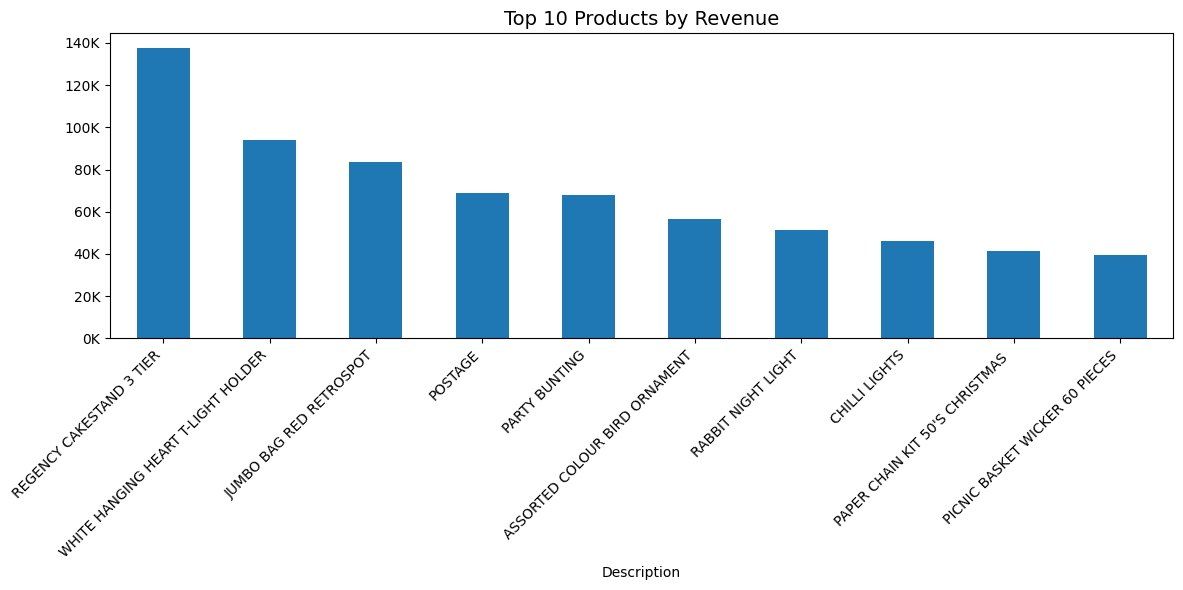

In [38]:
top_revenue_products = (
    df_model.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
# Plot
ax = top_revenue_products.plot(kind="bar", figsize=(12, 6))

# Title
plt.title("Top 10 Products by Revenue", fontsize=14)

# Format y-axis to show values in 'K'
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1000)}K'))

# Rotate x-axis labels and make them smaller
plt.xticks(rotation=45, ha='right', fontsize=10)

# Optional: adjust layout so labels fit nicely
plt.tight_layout()

plt.show()

Revenue by Country

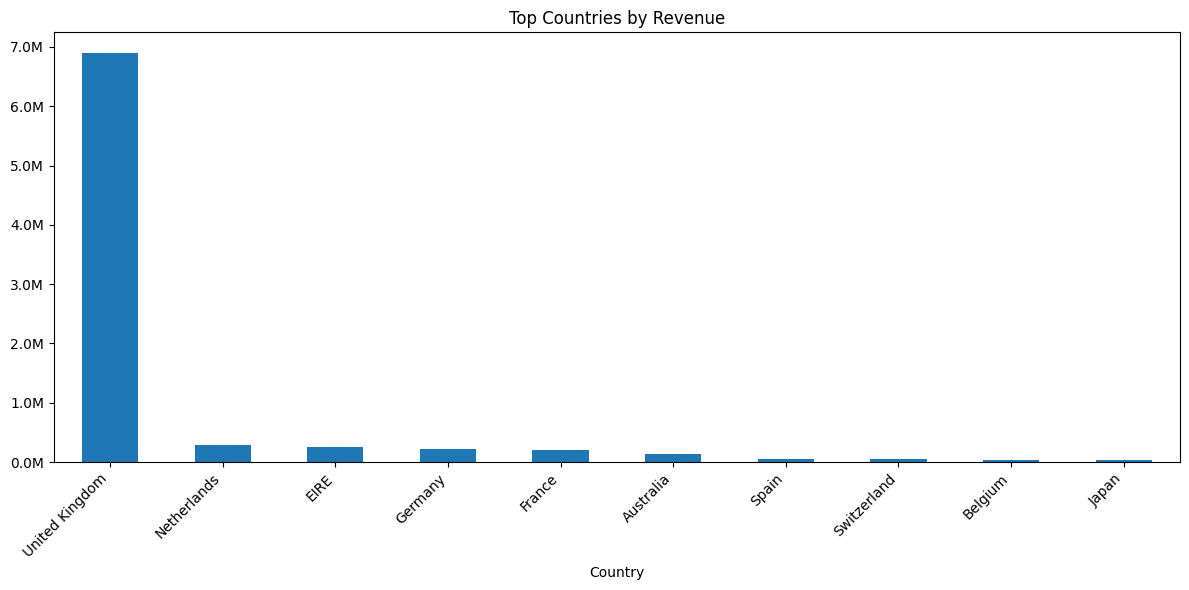

In [39]:
revenue_by_country = (
    df_model.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

ax = revenue_by_country.plot(kind="bar", figsize=(12,6))

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f}M'))

plt.title("Top Countries by Revenue")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Number of Customers per Country

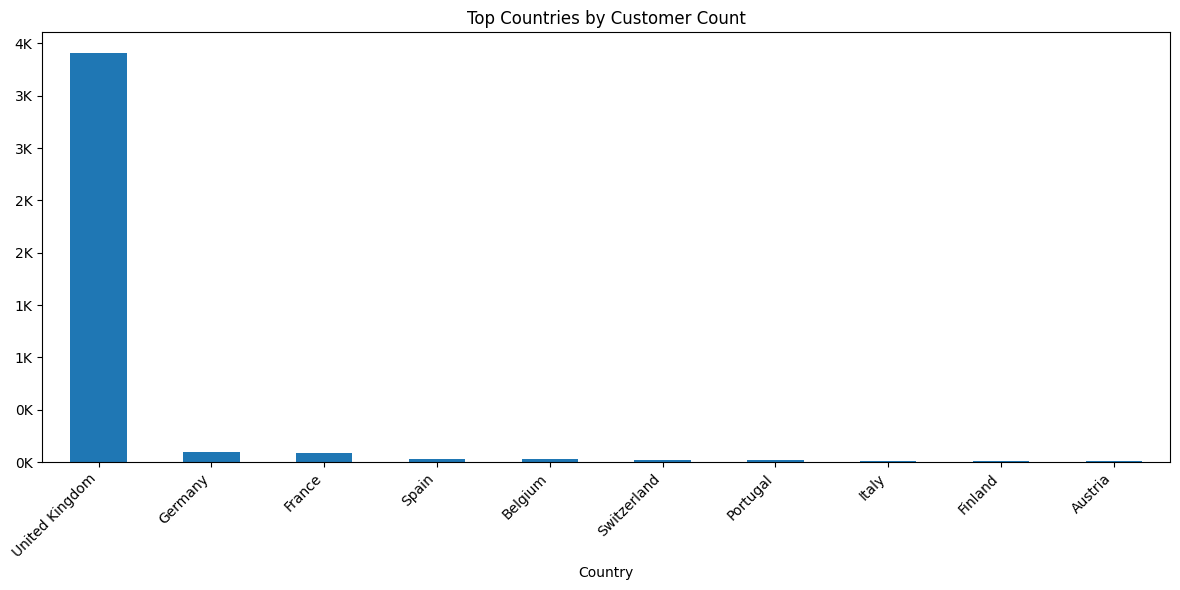

In [40]:
customers_by_country = (
    df_model.groupby("Country")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)
ax = customers_by_country.plot(kind="bar", figsize=(12,6))

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1000)}K'))

plt.title("Top Countries by Customer Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

start and end date
FOR REPORT: The dataset spans from December 2010 to December 2011, providing approximately one year of transactional data for analysis.

In [41]:
start_date = df_model.index.min()
end_date = df_model.index.max()
print("Start Date:", start_date.strftime("%Y-%m-%d"))
print("End Date:", end_date.strftime("%Y-%m-%d"))

Start Date: 2010-12-01
End Date: 2011-12-09


Monthly spend (time trend)
FOR REPORT: Monthly revenue was aggregated using time-series resampling to ensure a continuous monthly range from the start to the end of the dataset. Dates were formatted in a standard MMM-YY format to improve readability. The final month in the dataset was excluded from the analysis as it represents a partial period and would otherwise distort the observed revenue trend.

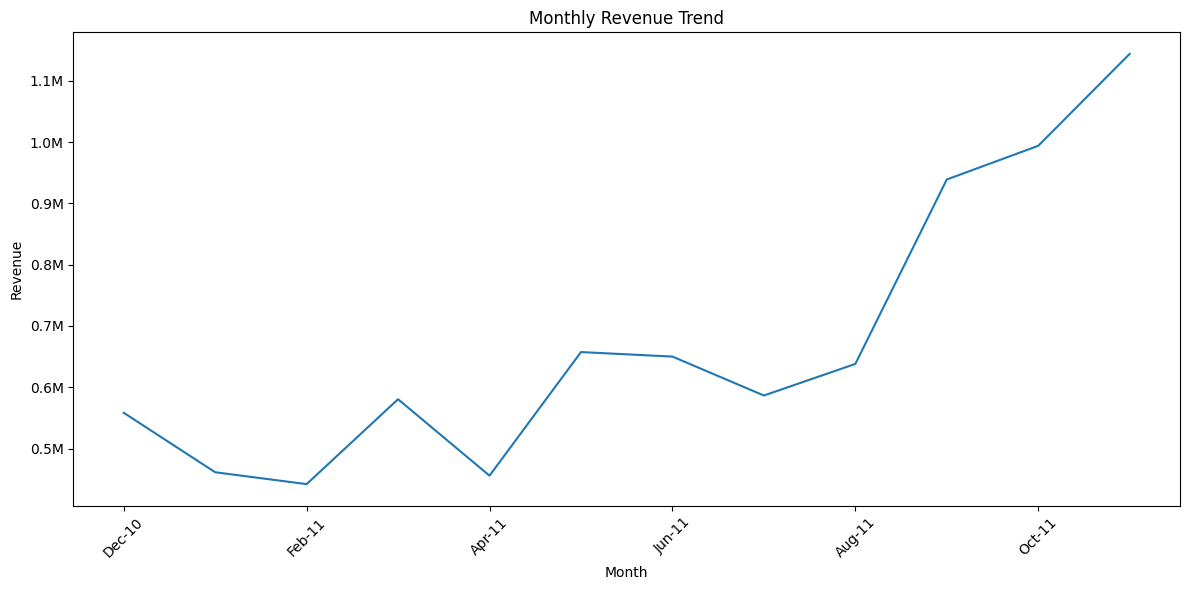

In [42]:
# Monthly aggregation from start month to end month

monthly_spend = (
    df_model["TotalPrice"]
    .resample("ME")
    .sum()
)

# Remove last (incomplete) month
monthly_spend = monthly_spend.iloc[:-1]

# Format index as MMM-YY
monthly_spend.index = monthly_spend.index.strftime("%b-%y")

# Plot
ax = monthly_spend.plot(figsize=(12,6))

# Format y-axis in millions
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f}M")
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Cancellation analysis

In [43]:
cancelled = df_clean[
    df_clean["InvoiceNo"].astype(str).str.startswith("C")
]
cancelled_orders = cancelled["InvoiceNo"].nunique()
total_orders = df_model["InvoiceNo"].nunique()
print("Cancelled Orders:", cancelled_orders)
print("Total Orders:", total_orders)

print("Cancellation rate:", cancelled_orders / total_orders)

Cancelled Orders: 3654
Total Orders: 18368
Cancellation rate: 0.1989329268292683


# 6. Model Training

# 7. Evaluation

# 8. Save Outputs